<a href="https://colab.research.google.com/github/varun0852/for-study/blob/master/Logistic_Regression_Theory_%2B_Coding_%26_Evaluation_Metrics_mp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import chi2_contingency, f_oneway
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
ch = pd.read_csv("Bank Customer Churn Prediction.csv")
ch

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## EDA

In [ ]:
ch.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


### Checking Corruoted Values

In [ ]:
# we are checking corrupted values for credit_score
cc = ch["credit_score"]<0
# set(cc)
cc.value_counts()

,count
credit_score,
False,10000


In [ ]:
# # we are checking coeeupted records
# for columns in ch[1:]:
#   print(columns, "\n")
#   print(set(ch[columns]))
#   print("\n")


In [ ]:
# we are checking value counts of country
ch["country"].value_counts()

,count
country,
France,5014
Germany,2509
Spain,2477


In [ ]:
# we are checking value counts of gender
ch["gender"].value_counts()

,count
gender,
Male,5457
Female,4543


In [ ]:
# we are checking value counts of age
ch["age"].value_counts()

,count
age,
37,478
38,477
35,474
36,456
34,447
...,...
84,2
82,1
88,1


In [ ]:
# we are checking value counts of tenure
ch["tenure"].value_counts()

,count
tenure,
2,1048
1,1035
7,1028
8,1025
5,1012
3,1009
4,989
9,984
6,967


In [ ]:
# we are checking value counts of balance
ch["balance"].value_counts()

,count
balance,
0.00,3617
130170.82,2
105473.74,2
159397.75,1
144238.70,1
...,...
108698.96,1
238387.56,1
111833.47,1


In [ ]:
# we are checking value counts of products_number
ch["products_number"].value_counts()

,count
products_number,
1,5084
2,4590
3,266
4,60


In [ ]:
# we are checking value counts of credit_card
ch["credit_card"].value_counts()

,count
credit_card,
1,7055
0,2945


In [ ]:
# we are checking value counts of active_member
ch["active_member"].value_counts()

,count
active_member,
1,5151
0,4849


In [ ]:
# we are checking value counts of estimated_salary
ch["estimated_salary"].value_counts()

,count
estimated_salary,
24924.92,2
121505.61,1
89874.82,1
72500.68,1
182692.80,1
...,...
188377.21,1
55902.93,1
4523.74,1


### Checking Duplicates values

In [ ]:
cc1 = ch.drop(columns =["customer_id"])
cc1

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
cc1.duplicated().value_counts()

,count
False,10000


churn
0    7963
1    2037
Name: count, dtype: int64


/tmp/ipython-input-2611822660.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(cc1["churn"]))


<Axes: xlabel='churn', ylabel='count'>

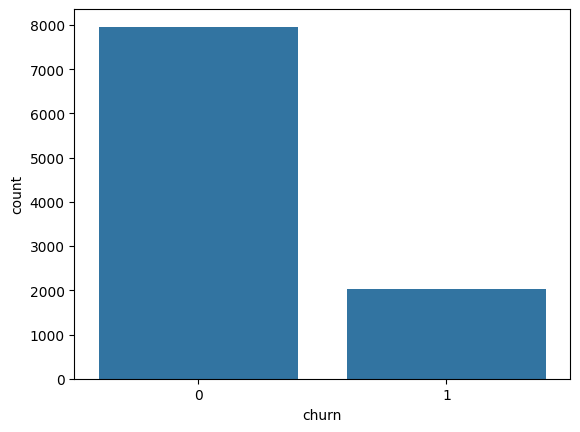

In [ ]:
print(pd.value_counts(cc1["churn"]))
sns.countplot(x = "churn" , data = cc1)

### Checking data distribution of continouns data

/tmp/ipython-input-513414956.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cc1["credit_score"])


<Axes: xlabel='credit_score', ylabel='Density'>

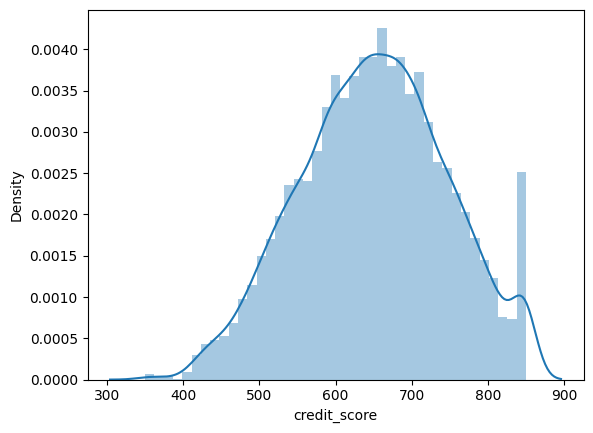

In [ ]:
sns.distplot(cc1["credit_score"])

/tmp/ipython-input-1485982479.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cc1["age"])


<Axes: xlabel='age', ylabel='Density'>

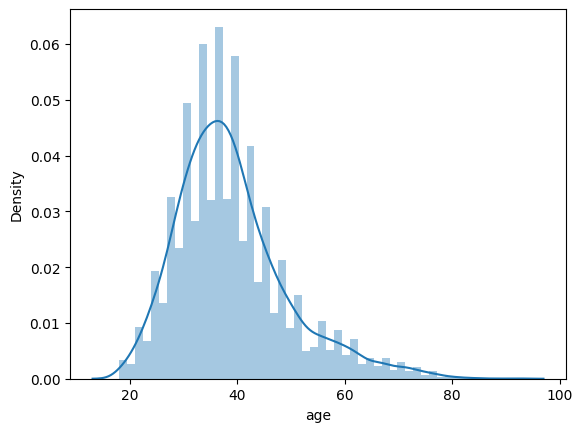

In [ ]:
sns.distplot(cc1["age"])

/tmp/ipython-input-947530483.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cc1["balance"])


<Axes: xlabel='balance', ylabel='Density'>

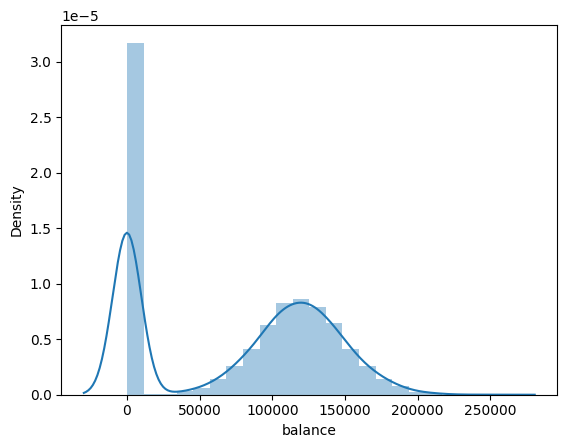

In [ ]:
sns.distplot(cc1["balance"])

/tmp/ipython-input-3463931032.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cc1["estimated_salary"])


<Axes: xlabel='estimated_salary', ylabel='Density'>

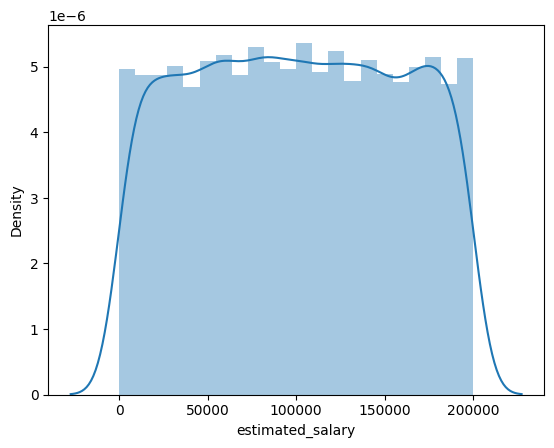

In [ ]:
sns.distplot(cc1["estimated_salary"])

### Checking Outliers

<Axes: >

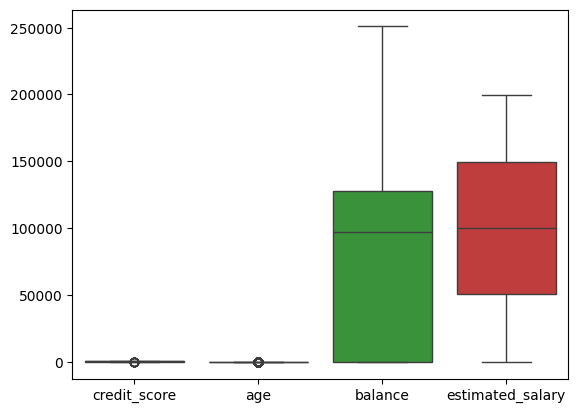

In [ ]:
continous_features = cc1[["credit_score" , "age" , "balance" , "estimated_salary"]]
sns.boxplot(continous_features)

<Axes: ylabel='credit_score'>

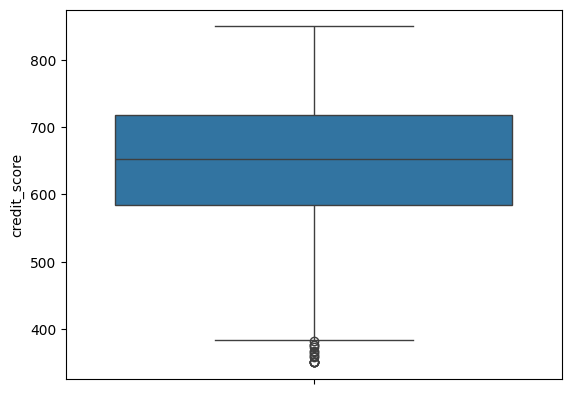

In [ ]:
sns.boxplot(continous_features["credit_score"])

<Axes: ylabel='age'>

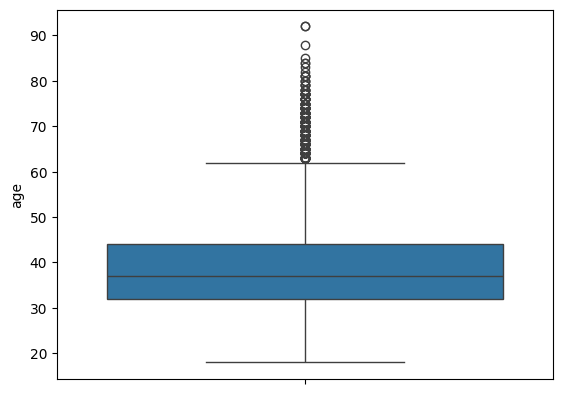

In [ ]:
sns.boxplot(continous_features["age"])

<Axes: ylabel='balance'>

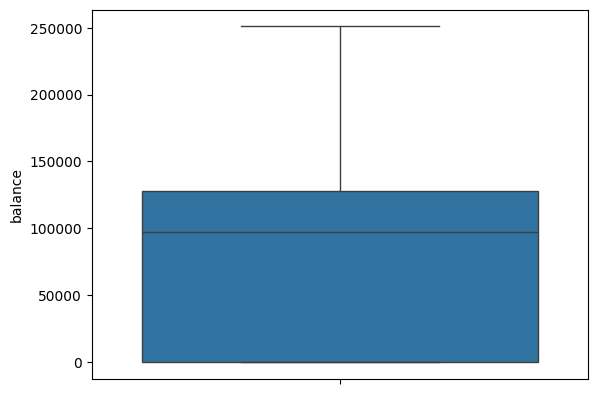

In [ ]:
sns.boxplot(continous_features["balance"])

<Axes: ylabel='estimated_salary'>

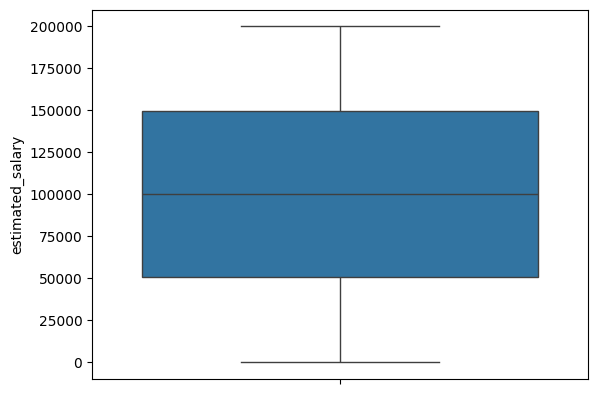

In [ ]:
sns.boxplot(continous_features["estimated_salary"])

### Outliers Removing

In [ ]:
from numpy._core.defchararray import upper
def outliers_removal(df , columns):
  q1 = df[columns].quantile(0.25)
  q3 = df[columns].quantile(0.75)
  iqr = q3-q1
  lower_fence = q1-1.5*iqr
  upper_fence = q3+1.5*iqr
  trimmed_features = df[(df[columns] > lower_fence) & (df[columns] < upper_fence)]
  return trimmed_features

cc3 = outliers_removal(cc1 , "credit_score")
cc4 = outliers_removal(cc1 , "age")


<Axes: ylabel='credit_score'>

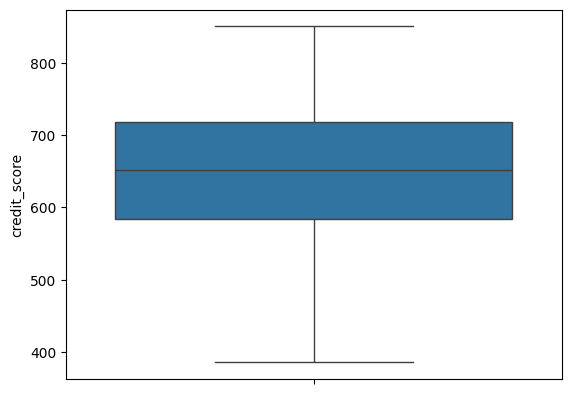

In [ ]:
sns.boxplot(cc3["credit_score"])

<Axes: ylabel='age'>

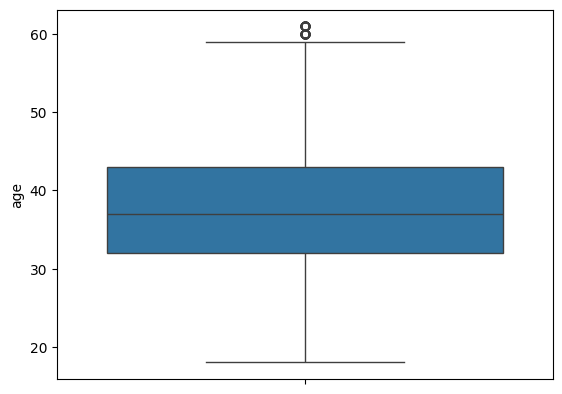

In [ ]:
sns.boxplot(cc4["age"])

### Data Transformation

In [ ]:
cc4

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
x = cc4.drop(columns = ["churn"])
y = cc4["churn"]

In [ ]:
min_max_scaler = MinMaxScaler() # the scale of the data will be between 0 to 1

cc_continous = x[["credit_score" , "age" , "balance" , "estimated_salary"]]


cc_normalized = min_max_scaler.fit_transform(cc_continous)



In [ ]:
cc_continous_normalized = pd.DataFrame(data = cc_normalized , columns = ["credit_score" , "age" , "balance" , "estimated_salary"] )
cc_continous_normalized

,credit_score,age,balance,estimated_salary
0,0.538,0.558140,0.000000,0.506735
1,0.516,0.534884,0.334031,0.562709
2,0.304,0.558140,0.636357,0.569654
3,0.698,0.488372,0.000000,0.469120
4,1.000,0.581395,0.500246,0.395400
...,...,...,...,...
9584,0.842,0.488372,0.000000,0.481341
9585,0.332,0.395349,0.228657,0.508490
9586,0.718,0.418605,0.000000,0.210390
9587,0.844,0.558140,0.299226,0.464429


### Performing Some Test On Catogorical Data

In [ ]:
# def chi2_test(column, churn):
#     contingency_table = pd.crosstab(column, churn)
#     chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

#     #print("Chi-Square statistic:", chi2_stat)
#     #print("p-value:", p_value)
#     #print("Degrees of Freedom:", dof)
#     #print("Expected frequencies:\n", expected)

#     # Interpretation
#     alpha = 0.05  # significance level
#     if p_value < alpha:
#         print("Reject the null hypothesis. There is a significant association between the two variables." )
#     else:
#         print("Fail to reject the null hypothesis. There is no significant association between the two variables.")




# x = ["country", "gender", "tenure", "products_number", "credit_card", "active_member"]
# for column in x:
#     print(column, "churn")
#     chi2_test(cc4[column], cc4["churn"])

country churn


TypeError: list indices must be integers or slices, not str

In [ ]:
# def anova(column, churn):
#     f_statistic, p_value = f_oneway(column, churn)

#     #print("F-statistic:", f_statistic)
#     #print("P-value:", p_value)

#     # Interpret the result
#     alpha = 0.05  # Common significance level (5%)

#     if p_value < alpha:
#         print("There is a statistically significant difference among the groups.")
#     else:
#         print("There is no statistically significant difference among the groups.")


# x = ["credit_score",  "age", "balance",  "estimated_salary"]
# for column in x:
#     print(column, "churn")
#     anova(cc4[column], cc4["churn"])


### Converting into One Hot Encoding

In [ ]:
cc_new = pd.get_dummies(ch , columns = ["country" , "gender"])
cc_new

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,gender_Female,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,True,False,False,False,True
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,True,False,False,False,True
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,True,False,False,True,False
9998,15682355,772,42,3,75075.31,2,1,0,92888.52,1,False,True,False,False,True


### Spliting the Data Training the data



In [ ]:
x = cc_new.drop(columns = ["customer_id" , "churn"])
y = cc_new["churn"]


In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42 , stratify= y)

In [ ]:
# training the model
regr = LogisticRegression()
regr.fit(x_train , y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Predicting training data
y_train_predictions = regr.predict(x_train)
training_accuracy = accuracy_score(y_train , y_train_predictions)
training_accuracy

0.793125

In [ ]:
# Predicting Testing Data
y_test_predictions = regr.predict(x_test)
testing_accuracy = accuracy_score(y_test , y_test_predictions)
testing_accuracy


0.7925

In [ ]:
# Printing Accuracy of both test and train
print("training accuracy:" , training_accuracy)
print("testing accuracy:" , testing_accuracy)

training accuracy: 0.793125
testing accuracy: 0.7925


In [ ]:
# Confusion metrix
confusion_matrix(y_test , y_test_predictions)

array([[1556,   37],
       [ 378,   29]])

In [ ]:
print(classification_report(y_test , y_test_predictions))

              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1593
           1       0.44      0.07      0.12       407

    accuracy                           0.79      2000
   macro avg       0.62      0.52      0.50      2000
weighted avg       0.73      0.79      0.73      2000

